In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-dataset/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.SA3.121.tiff
/kaggle/input/da

In [40]:
dataset_path = "//kaggle/input/datasets/navneet0094/jafee-dataset/"

print(os.listdir(dataset_path))

['jaffe', 'README_FIRST.txt']


In [41]:
from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe"

for img_name in os.listdir(dataset_path):
    img_path = os.path.join(dataset_path, img_name)

    try:
        img = Image.open(img_path).convert('L')  # grayscale
        img = img.resize((48,48))
        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error loading:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 48, 48)
Labels: [0 1 2 3 4 5 6]


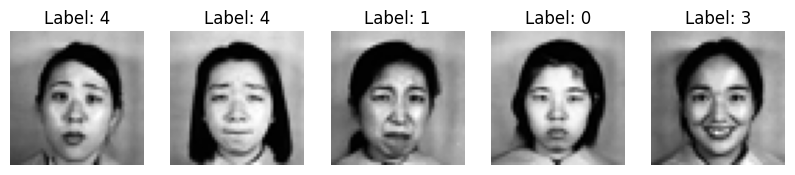

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [43]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 900)


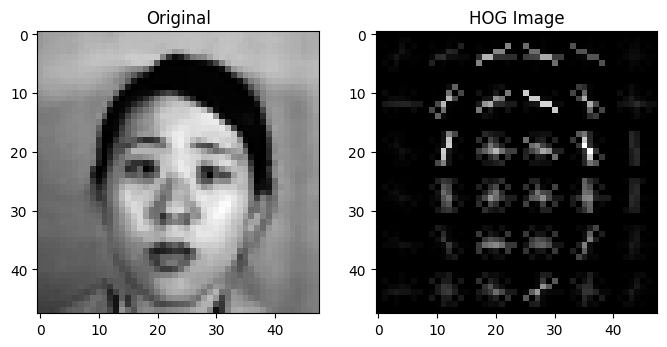

In [44]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import time

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, labels, test_size=0.3, random_state=42,shuffle=True
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)         

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)
hog_time = end - start

print("HOG Accuracy:", hog_acc)
print("HOG Time:", hog_time)

HOG Accuracy: 0.625
HOG Time: 0.011325597763061523


In [47]:
emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       1.00      0.36      0.53        11
     disgust       0.17      0.50      0.25         4
        fear       0.71      0.62      0.67         8
       happy       0.73      0.89      0.80         9
     sadness       0.42      0.71      0.53         7
    surprise       1.00      0.47      0.64        15
     neutral       0.82      0.90      0.86        10

    accuracy                           0.62        64
   macro avg       0.69      0.64      0.61        64
weighted avg       0.78      0.62      0.64        64



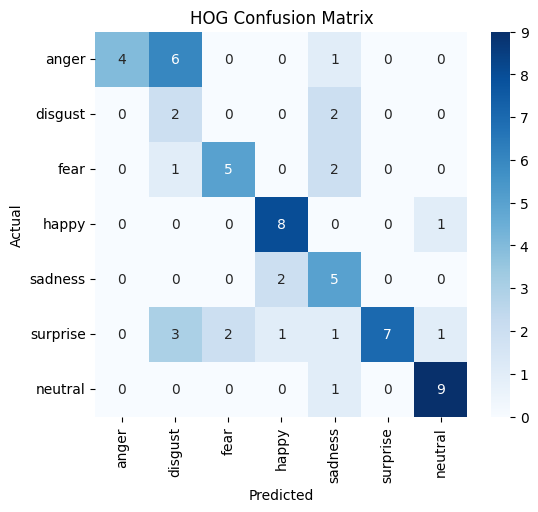

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

cv_scores = cross_val_score(pipeline, X_hog, labels, cv=10)

print("\n=== 10-Fold CV ===")
print("Fold Accuracies:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))


=== 10-Fold CV ===
Fold Accuracies: [0.81818182 0.77272727 0.81818182 0.66666667 0.76190476 0.71428571
 0.76190476 0.85714286 0.66666667 0.9047619 ]
Mean Accuracy: 0.7742424242424243
Std Dev: 0.0740376816644986


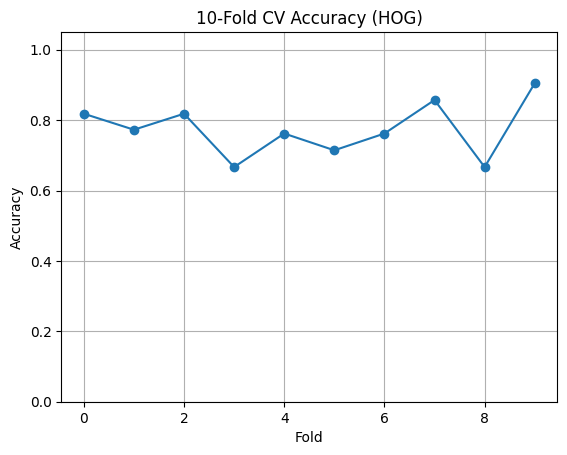

In [50]:
plt.plot(cv_scores, marker='o')
plt.title("10-Fold CV Accuracy (HOG)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid()
plt.show()

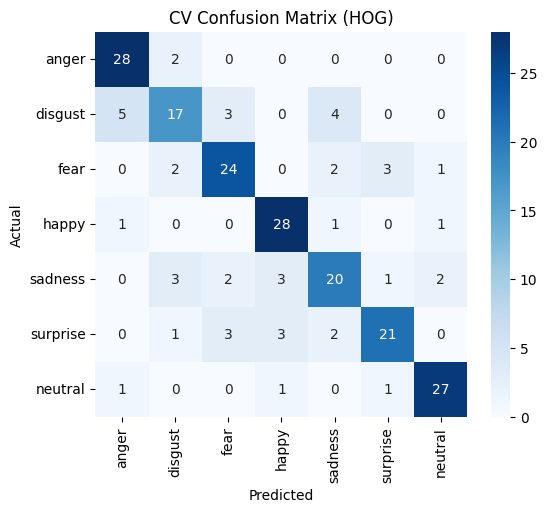

In [51]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# get predictions from CV
y_pred_cv = cross_val_predict(pipeline, X_hog, labels, cv=10)

# confusion matrix
cm = confusion_matrix(labels, y_pred_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("CV Confusion Matrix (HOG)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [52]:

# classification report
print(classification_report(labels, y_pred_cv, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       0.80      0.93      0.86        30
     disgust       0.68      0.59      0.63        29
        fear       0.75      0.75      0.75        32
       happy       0.80      0.90      0.85        31
     sadness       0.69      0.65      0.67        31
    surprise       0.81      0.70      0.75        30
     neutral       0.87      0.90      0.89        30

    accuracy                           0.77       213
   macro avg       0.77      0.77      0.77       213
weighted avg       0.77      0.77      0.77       213



In [53]:
# lightbgm
# xgboost 
# random forest 

In [54]:
from sklearn.ensemble import RandomForestClassifier

# model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()

rf_model.fit(X_train, y_train)

end = time.time()

y_pred_rf = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Time:", end - start)




RF Accuracy: 0.59375
RF Time: 0.4328160285949707


In [55]:
# report
print(classification_report(y_test, y_pred_rf, target_names=emotion_names))


              precision    recall  f1-score   support

       anger       0.86      0.55      0.67        11
     disgust       0.29      0.50      0.36         4
        fear       0.55      0.75      0.63         8
       happy       0.50      0.78      0.61         9
     sadness       0.56      0.71      0.62         7
    surprise       0.75      0.40      0.52        15
     neutral       0.75      0.60      0.67        10

    accuracy                           0.59        64
   macro avg       0.61      0.61      0.58        64
weighted avg       0.66      0.59      0.60        64



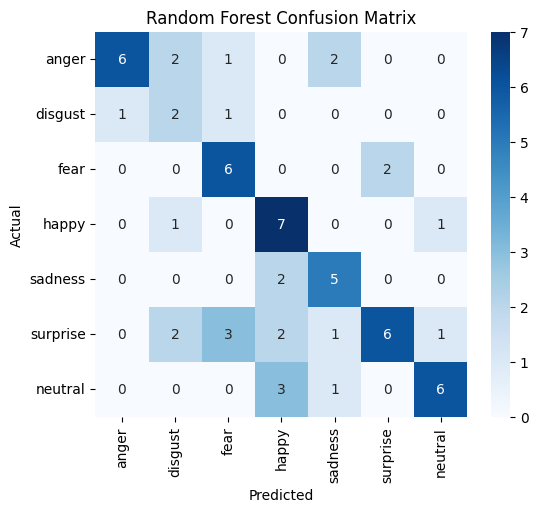

In [56]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_scores = cross_val_score(rf_pipeline, X_hog, labels, cv=10)
print("\n=== Random Forest CV ===")
print("Scores:", rf_scores)
print("Mean:", rf_scores.mean())
print("Std:", rf_scores.std())


=== Random Forest CV ===
Scores: [0.68181818 0.77272727 0.59090909 0.57142857 0.71428571 0.57142857
 0.71428571 0.76190476 0.52380952 0.76190476]
Mean: 0.6664502164502164
Std: 0.08856729201175274


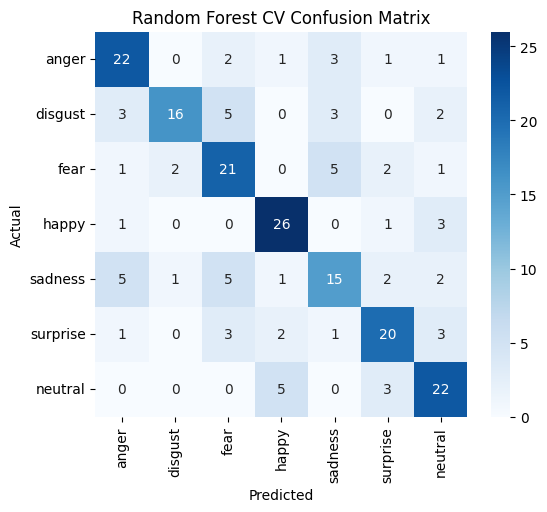

              precision    recall  f1-score   support

       anger       0.67      0.73      0.70        30
     disgust       0.84      0.55      0.67        29
        fear       0.58      0.66      0.62        32
       happy       0.74      0.84      0.79        31
     sadness       0.56      0.48      0.52        31
    surprise       0.69      0.67      0.68        30
     neutral       0.65      0.73      0.69        30

    accuracy                           0.67       213
   macro avg       0.68      0.67      0.66       213
weighted avg       0.67      0.67      0.66       213



In [59]:
from sklearn.model_selection import cross_val_predict

y_pred_rf_cv = cross_val_predict(rf_model, X_hog, labels, cv=10)

cm_rf = confusion_matrix(labels, y_pred_rf_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("Random Forest CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(labels, y_pred_rf_cv, target_names=emotion_names))

In [60]:
!pip install xgboost

In [61]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    # use_label_encoder=False,
    eval_metric='mlogloss'
)

start = time.time()

xgb_model.fit(X_train, y_train)

end = time.time()

y_pred_xgb = xgb_model.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB Time:", end - start)


XGB Accuracy: 0.546875
XGB Time: 7.90654993057251


In [62]:

print(classification_report(y_test, y_pred_xgb, target_names=emotion_names))



              precision    recall  f1-score   support

       anger       0.80      0.36      0.50        11
     disgust       0.33      0.50      0.40         4
        fear       0.60      0.75      0.67         8
       happy       0.46      0.67      0.55         9
     sadness       0.30      0.43      0.35         7
    surprise       0.88      0.47      0.61        15
     neutral       0.58      0.70      0.64        10

    accuracy                           0.55        64
   macro avg       0.56      0.55      0.53        64
weighted avg       0.63      0.55      0.55        64



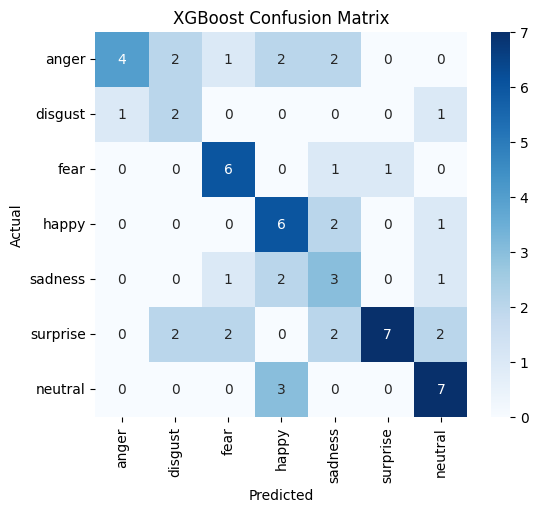

In [63]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss'
)

xgb_scores = cross_val_score(xgb_model, X_hog, labels, cv=10)

print("\n=== XGBoost CV ===")
print("Scores:", xgb_scores)
print("Mean:", xgb_scores.mean())
print("Std:", xgb_scores.std())


=== XGBoost CV ===
Scores: [0.5        0.54545455 0.59090909 0.47619048 0.61904762 0.66666667
 0.57142857 0.66666667 0.57142857 0.61904762]
Mean: 0.5826839826839827
Std: 0.060527159524963806


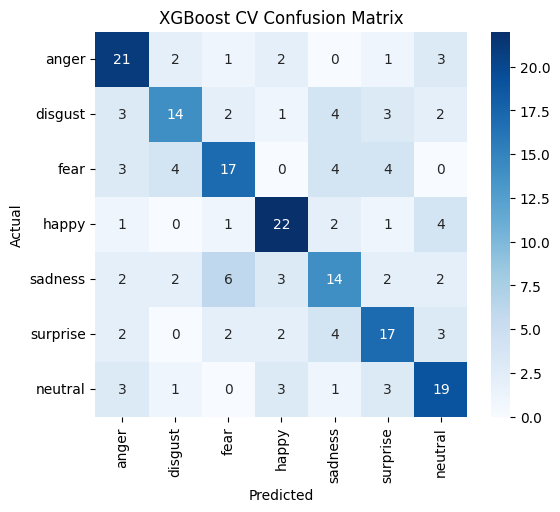

              precision    recall  f1-score   support

       anger       0.60      0.70      0.65        30
     disgust       0.61      0.48      0.54        29
        fear       0.59      0.53      0.56        32
       happy       0.67      0.71      0.69        31
     sadness       0.48      0.45      0.47        31
    surprise       0.55      0.57      0.56        30
     neutral       0.58      0.63      0.60        30

    accuracy                           0.58       213
   macro avg       0.58      0.58      0.58       213
weighted avg       0.58      0.58      0.58       213



In [65]:
y_pred_xgb_cv = cross_val_predict(xgb_model, X_hog, labels, cv=10)

cm_xgb = confusion_matrix(labels, y_pred_xgb_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("XGBoost CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(labels, y_pred_xgb_cv, target_names=emotion_names))

In [66]:
!pip install lightgbm

In [67]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    verbose=-1  
)

start = time.time()

lgb_model.fit(X_train, y_train)

end = time.time()

y_pred_lgb = lgb_model.predict(X_test)

print("LGB Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LGB Time:", end - start)


LGB Accuracy: 0.578125
LGB Time: 1.5583257675170898


In [68]:

print(classification_report(y_test, y_pred_lgb, target_names=emotion_names))



              precision    recall  f1-score   support

       anger       0.57      0.36      0.44        11
     disgust       0.29      0.50      0.36         4
        fear       0.70      0.88      0.78         8
       happy       0.67      0.67      0.67         9
     sadness       0.33      0.57      0.42         7
    surprise       0.88      0.47      0.61        15
     neutral       0.64      0.70      0.67        10

    accuracy                           0.58        64
   macro avg       0.58      0.59      0.56        64
weighted avg       0.64      0.58      0.58        64



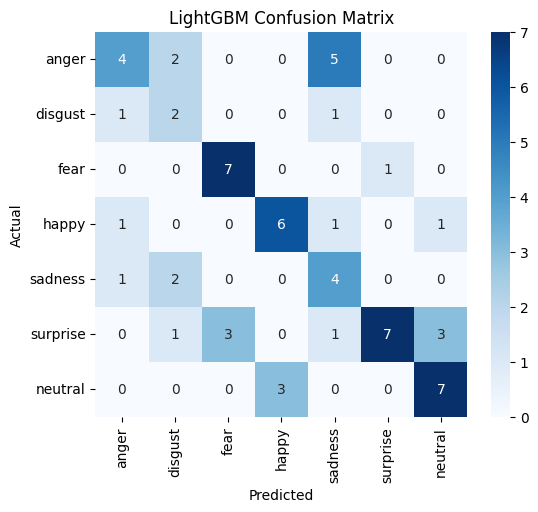

In [69]:
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    verbose=-1   
)

lgb_scores = cross_val_score(lgb_model, X_hog, labels, cv=10)

print("\n=== LightGBM CV ===")
print("Scores:", lgb_scores)
print("Mean:", lgb_scores.mean())
print("Std:", lgb_scores.std())


=== LightGBM CV ===
Scores: [0.63636364 0.63636364 0.63636364 0.57142857 0.61904762 0.66666667
 0.42857143 0.71428571 0.57142857 0.71428571]
Mean: 0.6194805194805194
Std: 0.07881760535257092


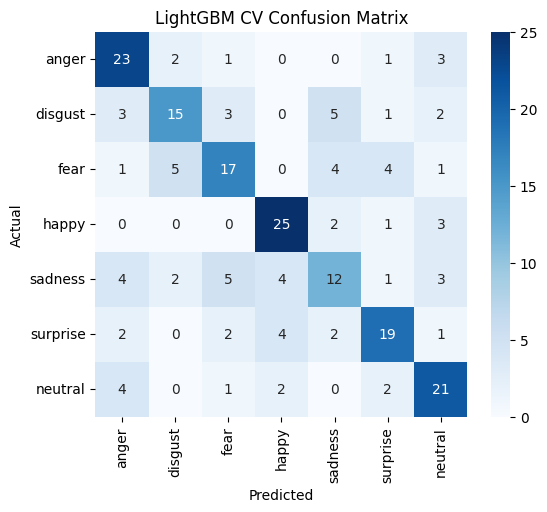

              precision    recall  f1-score   support

       anger       0.62      0.77      0.69        30
     disgust       0.62      0.52      0.57        29
        fear       0.59      0.53      0.56        32
       happy       0.71      0.81      0.76        31
     sadness       0.48      0.39      0.43        31
    surprise       0.66      0.63      0.64        30
     neutral       0.62      0.70      0.66        30

    accuracy                           0.62       213
   macro avg       0.61      0.62      0.61       213
weighted avg       0.61      0.62      0.61       213



In [71]:
y_pred_lgb_cv = cross_val_predict(lgb_model, X_hog, labels, cv=10)

cm_lgb = confusion_matrix(labels, y_pred_lgb_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("LightGBM CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(labels, y_pred_lgb_cv, target_names=emotion_names))

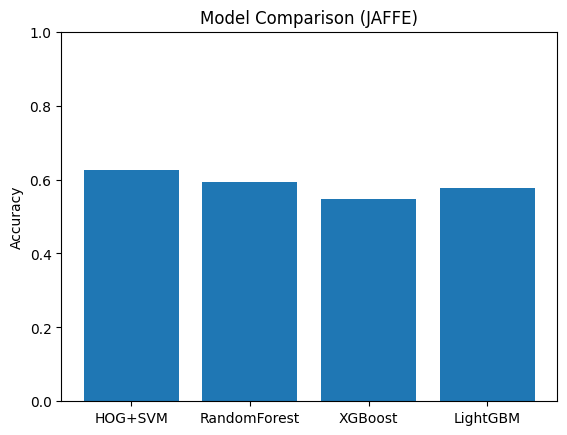

In [72]:
methods = ['HOG+SVM', 'RandomForest', 'XGBoost', 'LightGBM']
accuracy = [
    hog_acc,
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb)
]

plt.bar(methods, accuracy)
plt.title("Model Comparison (JAFFE)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

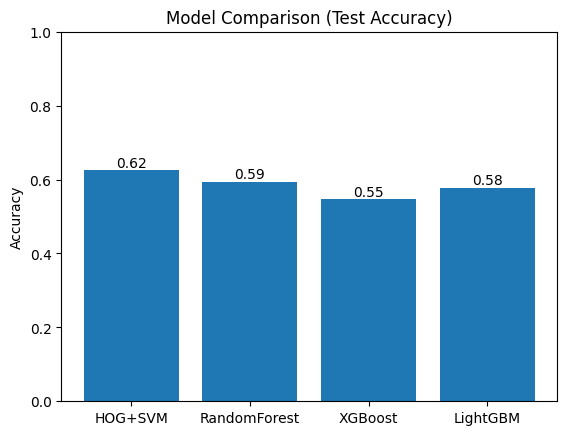

In [73]:
import matplotlib.pyplot as plt

methods = ['HOG+SVM', 'RandomForest', 'XGBoost', 'LightGBM']
accuracy = [
    hog_acc,
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb)
]

bars = plt.bar(methods, accuracy)

# Add labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.title("Model Comparison (Test Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

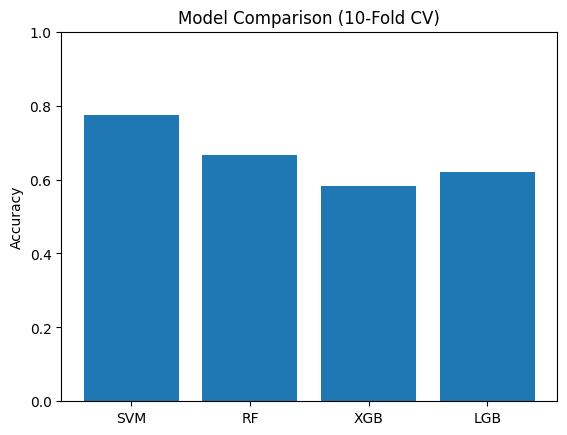

In [74]:
methods = ['SVM', 'RF', 'XGB', 'LGB']
means = [
    cv_scores.mean(),
    rf_scores.mean(),
    xgb_scores.mean(),
    lgb_scores.mean()
]

plt.bar(methods, means)
plt.title("Model Comparison (10-Fold CV)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

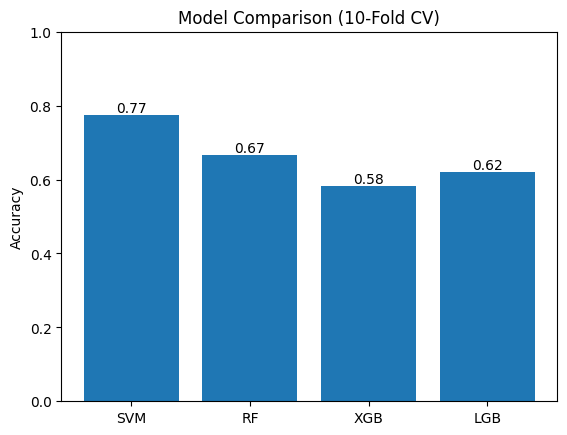

In [75]:
methods = ['SVM', 'RF', 'XGB', 'LGB']
means = [
    cv_scores.mean(),
    rf_scores.mean(),
    xgb_scores.mean(),
    lgb_scores.mean()
]

bars = plt.bar(methods, means)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.title("Model Comparison (10-Fold CV)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

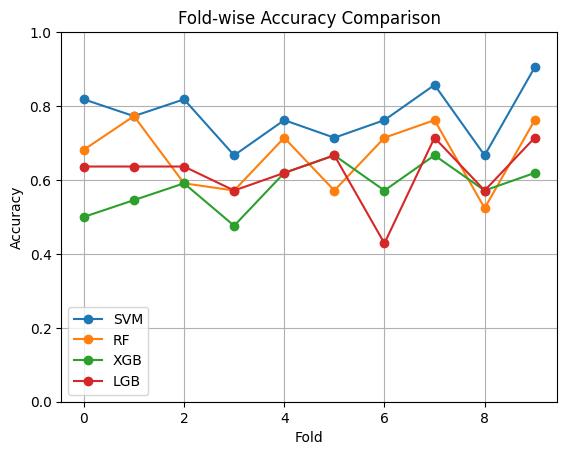

In [76]:
plt.plot(cv_scores, marker='o', label='SVM')
plt.plot(rf_scores, marker='o', label='RF')
plt.plot(xgb_scores, marker='o', label='XGB')
plt.plot(lgb_scores, marker='o', label='LGB')

plt.legend()
plt.title("Fold-wise Accuracy Comparison")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.show()